In [85]:
import gffpandas.gffpandas as gffpd
import pandas as pd
import numpy as np

### Working with Control pH 5 & 7, ArsS deletion pH 5 & 7

In [86]:
ctrl_ph7 = gffpd.read_gff3('gff_files/sample1_modification.gff') #Wild Type pH 7
arss_ph7 = gffpd.read_gff3('gff_files/sample2_modification.gff') #ArsS deletion pH 7, cannot detect pH change
ctrl_ph5 = gffpd.read_gff3('gff_files/sample5_modification.gff') #wild type pH 5
arss_ph5 = gffpd.read_gff3('gff_files/sample6_modification.gff') #ArsS deletion pH 5

#NOTE ANNOT, COUNTS, AND FREQ ARE ALL DATA FRAMES, NOT GFF DATA FRAMES
annot = pd.read_csv("csv_files/hpy_annot.csv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean

tss = pd.read_csv("csv_files/TSS.csv")

In [87]:
ctrl_ph7 = ctrl_ph7.attributes_to_columns()
ctrl_ph5 = ctrl_ph5.attributes_to_columns()

arss_ph7 = arss_ph7.attributes_to_columns()
arss_ph5 = arss_ph5.attributes_to_columns()

In [88]:
ctrl_ph7 = ctrl_ph7[ctrl_ph7['IPDRatio'] >= '2']
ctrl_ph5 = ctrl_ph5[ctrl_ph5['IPDRatio'] >= '2']

arss_ph7 = arss_ph7[arss_ph7['IPDRatio'] >= '2']
arss_ph5 = arss_ph5[arss_ph5['IPDRatio'] >= '2']

In [89]:
counts = pd.read_csv('csv_files/gene_counts.csv')
genome = pd.read_csv('csv_files/genetic_regions.csv')

In [90]:
# merging samples
frames = [ctrl_ph7, ctrl_ph5, arss_ph7, arss_ph5]
keys = ['ctrl pH7', 'ctrl pH5', 'arsS pH7', 'arsS pH5']
merged = pd.concat(frames, keys = keys)
merged = merged.reset_index(level=0).rename(columns={'level_0': 'sample'})
merged


,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA


In [12]:
ctrl_ph7[ctrl_ph7['motif'] == 'GCGTAC']

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
2854,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,56287,56287,417,-,.,context=TTTAGTTTGTTTTCTAGCGTACGAACAGGCACTAAAGA...,3.79,TTTAGTTTGTTTTCTAGCGTACGAACAGGCACTAAAGAGGC,430,GCGTAC,381,GCGTAC
5903,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,110235,110235,531,-,.,context=CCTAAATACGATGGAGGCGTACCGGAGAAAAAATTCGC...,4.23,CCTAAATACGATGGAGGCGTACCGGAGAAAAAATTCGCCTA,473,GCGTAC,497,GCGTAC
8950,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,169435,169435,512,+,.,context=TATAGGAACGCCAAAGGCGTACAGAAGGATTTGAAAAA...,4.02,TATAGGAACGCCAAAGGCGTACAGAAGGATTTGAAAAAAGC,463,GCGTAC,373,GCGTAC
14606,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,274627,274627,443,-,.,context=CGCTATAAGGTTTTCTGCGTACCGCTTCGGTCAATTGC...,3.89,CGCTATAAGGTTTTCTGCGTACCGCTTCGGTCAATTGCCCG,435,GCGTAC,405,GCGTAC
16738,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,317952,317952,511,+,.,context=CTAAAGAAGATTATGTGCGTACCGCTAAAGCTAAGGGG...,3.82,CTAAAGAAGATTATGTGCGTACCGCTAAAGCTAAGGGGTGT,539,GCGTAC,493,GCGTAC
22442,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,425032,425032,486,+,.,context=GTTCGACTCCCTTCGGGCGTACCACCTAACATTAATAC...,4.65,GTTCGACTCCCTTCGGGCGTACCACCTAACATTAATACCAT,399,GCGTAC,469,GCGTAC
23688,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,447913,447913,666,-,.,context=GTTCTGAACCCAGCTCGCGTACCGCTTTAAATGGCGAA...,4.97,GTTCTGAACCCAGCTCGCGTACCGCTTTAAATGGCGAACAG,592,GCGTAC,638,GCGTAC
33555,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,653453,653453,594,-,.,context=ATGTAGCCTAAATAAGGCGTACTAGAATGGAGCAATTG...,5.34,ATGTAGCCTAAATAAGGCGTACTAGAATGGAGCAATTGCCC,441,GCGTAC,580,GCGTAC
35579,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,693063,693063,483,+,.,context=ATCAAAAACCTTAAAAGCGTACCAGCTTTAGAAAAACT...,4.35,ATCAAAAACCTTAAAAGCGTACCAGCTTTAGAAAAACTGAA,425,GCGTAC,456,GCGTAC
36107,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,702147,702147,224,+,.,context=TGAGCGTAGAAGAGGGGCGTACTGGGCAGTTGCAATTT...,3.27,TGAGCGTAGAAGAGGGGCGTACTGGGCAGTTGCAATTTGGG,382,GCGTAC,274,GCGTAC


In [91]:
ctrl_ph7[ctrl_ph7['type'] == 'm4C']

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
28,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,531,531,618,+,.,context=GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAG...,4.71,GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAGCGA,548,GAAGA/TCTTC,605,TCTTC
32,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,564,564,274,+,.,context=AGAAGCGATTTTTTTAATTTCTTCATTACCGCTCTCAA...,2.60,AGAAGCGATTTTTTTAATTTCTTCATTACCGCTCTCAAACG,550,GAAGA/TCTTC,231,TCTTC
64,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1089,1089,278,+,.,coverage=563;context=TCCCTTGTAATTGCAATTTCCCTTC...,2.85,TCCCTTGTAATTGCAATTTCCCTTCTATGATTTGCATGAAA,563,None,168,None
123,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2192,2192,426,+,.,context=TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTA...,3.33,TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTAAAA,523,GAAGA/TCTTC,426,TCTTC
145,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2549,2549,144,+,.,context=CTCATAAAGCTCTTTAAGCTCTTCATATTCATTCTCTT...,2.18,CTCATAAAGCTCTTTAAGCTCTTCATATTCATTCTCTTGAA,525,GAAGA/TCTTC,119,TCTTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86410,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1666626,1666626,378,+,.,context=GCTCCCATAGTATTGCAACTCTTCAGCGATTCTTTCTG...,3.09,GCTCCCATAGTATTGCAACTCTTCAGCGATTCTTTCTGCGT,540,GAAGA/TCTTC,387,TCTTC
86443,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667451,1667451,132,-,.,coverage=564;context=AAAAGTTTGGAAAAAATGAGCGATG...,2.01,AAAAGTTTGGAAAAAATGAGCGATGAGGAGATTAGAGAGCT,564,None,32,None
86448,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667498,1667498,572,+,.,context=AATGCTAGAGAGCATGTTTTCTTCAATCAAAGTTGTGT...,4.09,AATGCTAGAGAGCATGTTTTCTTCAATCAAAGTTGTGTCAG,563,GAAGA/TCTTC,537,TCTTC
86459,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667636,1667636,352,+,.,context=GCCCCCATAACGCTGCAATTCTTCAGCGATCCTTCTTG...,2.90,GCCCCCATAACGCTGCAATTCTTCAGCGATCCTTCTTGGGT,554,GAAGA/TCTTC,359,TCTTC


In [92]:
ctrl_ph5['motif'].value_counts()
#ctrl_ph5['motif'].value_counts()

#arss_ph7['motif'].value_counts()
#arss_ph5['motif'].value_counts()

motif
CATG                   14752
GATC                   10305
GANTC                   5236
TCTTC                   4767
RCGDAD                  4634
GAGG                    4526
GAAGA                   4308
GCAG                    4257
DGAAGG                  1135
ATTAAT                   952
YCGRATD                  469
HTCAVNNNNNNTGY           385
CTANNNNNNNNTGT           330
TCGA                     323
ACANNNNNNNNTAG           314
GAGG,GAAGA               240
RCGDAD,GATC              194
TCGA,GATC                186
GAAGA,GANTC              135
GAAGA,GATC               132
TCGA,GANTC                83
RCGDAD,GAGG               79
ACAGNNNNNNTGA             73
RCGDAD,GANTC              73
GCGCGVATNNNNNNNH          60
YCGAATC                   58
YCGRATD,GANTC             30
YCGAAGG                   21
GCGTAC                    19
TCGA,GAGG                 16
ACANNNNNNNNTAG,CATG       16
Name: count, dtype: int64

In [19]:

ctrl_ph5.to_csv('csv_files/ctrl5.csv')

In [93]:
ctrl_ph5

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,513,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.12,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,474,GAGG,484,GAGG
3,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,646,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,6.22,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,475,GANTC,596,GANTC
4,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,548,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.71,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,473,GANTC,535,GANTC
7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,626,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.39,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,480,RCGDAD,582,RCGDAD
13,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,623,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.59,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,470,RCGDAD,590,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85746,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,686,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.92,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,468,GATC,726,GATC
85748,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,506,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.72,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,454,DGAAGG,475,DGAAGG
85749,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,469,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.21,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,459,RCGDAD,460,RCGDAD
85753,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,638,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.27,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,469,GAAGA/TCTTC,665,GAAGA


In [94]:
ctrl_ph7.columns

Index(['seq_id', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase',
       'attributes', 'IPDRatio', 'context', 'coverage', 'id',
       'identificationQv', 'motif'],
      dtype='object')

In [95]:
ctrl_ph7[ctrl_ph7['start'] <= 17197]

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17147,17147,485,+,.,context=ACGCAAAGCGCTTTTACAAGAGGGGCTGGTTATGTGGG...,4.42,ACGCAAAGCGCTTTTACAAGAGGGGCTGGTTATGTGGGCGC,444,GAGG,453,GAGG
896,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17172,17172,571,+,.,context=CTGGTTATGTGGGCGCTACCATGATTAATGATAATGTG...,5.23,CTGGTTATGTGGGCGCTACCATGATTAATGATAATGTGCGC,445,CATG,523,CATG
897,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17173,17173,473,-,.,context=CGCGCACATTATCATTAATCATGGTAGCGCCCACATAA...,4.44,CGCGCACATTATCATTAATCATGGTAGCGCCCACATAACCA,440,CATG,451,CATG
898,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17176,17176,576,-,.,context=AAGCGCGCACATTATCATTAATCATGGTAGCGCCCACA...,5.33,AAGCGCGCACATTATCATTAATCATGGTAGCGCCCACATAA,433,ATTAAT,597,ATTAAT


In [17]:
counts = pd.DataFrame(columns=['gene', '1\' pH7','1\' pH5', '16\' pH7', '16\' pH5'])
counts['gene'] = annot['HP_number']
counts.head()

,gene,1' pH7,1' pH5,16' pH7,16' pH5
0,HP0001,NaN,NaN,NaN,NaN
1,HP0002,NaN,NaN,NaN,NaN
2,HP0003,NaN,NaN,NaN,NaN
3,HP0004,NaN,NaN,NaN,NaN
4,HP0005,NaN,NaN,NaN,NaN


In [96]:
for ind in counts.index: 
    counts.loc[ind, '1\' pH7']=((ctrl_ph7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '1\' pH5']=((ctrl_ph5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '16\' pH7']=((arss_ph7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '16\' pH5']=((arss_ph5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [97]:
counts

,Unnamed: 0,gene,1' pH7,1' pH5,16' pH7,16' pH5,1' pH7 density,16' pH7 density,1' pH5 density,16' pH5 density
0,0,HP0001,16,16,16,16,0.038741,0.038741,0.038741,0.038741
1,1,HP0002,25,26,24,24,0.053533,0.051392,0.055675,0.051392
2,2,HP0003,31,31,31,31,0.037485,0.037485,0.037485,0.037485
3,3,HP0004,27,27,25,24,0.040785,0.037764,0.040785,0.036254
4,4,HP0005,22,23,24,23,0.032353,0.035294,0.033824,0.033824
...,...,...,...,...,...,...,...,...,...,...
1585,1585,HP1586,8,8,8,8,0.023881,0.023881,0.023881,0.023881
1586,1586,HP1587,24,24,24,24,0.051724,0.051724,0.051724,0.051724
1587,1587,HP1588,32,32,32,32,0.042216,0.042216,0.042216,0.042216
1588,1588,HP1589,29,29,28,28,0.046774,0.045161,0.046774,0.045161


In [19]:
for ind in counts.index:
    gene_length = annot.loc[ind,'end'] - annot.loc[ind,'start']
    counts.loc[ind, '1\' pH7 density'] = counts.loc[ind, '1\' pH7'] / gene_length
    counts.loc[ind, '16\' pH7 density'] = counts.loc[ind, '16\' pH7'] / gene_length
    counts.loc[ind, '1\' pH5 density'] = counts.loc[ind, '1\' pH5'] / gene_length
    counts.loc[ind, '16\' pH5 density'] = counts.loc[ind, '16\' pH5'] / gene_length
    #density is percentage? 

In [98]:
counts

,Unnamed: 0,gene,1' pH7,1' pH5,16' pH7,16' pH5,1' pH7 density,16' pH7 density,1' pH5 density,16' pH5 density
0,0,HP0001,16,16,16,16,0.038741,0.038741,0.038741,0.038741
1,1,HP0002,25,26,24,24,0.053533,0.051392,0.055675,0.051392
2,2,HP0003,31,31,31,31,0.037485,0.037485,0.037485,0.037485
3,3,HP0004,27,27,25,24,0.040785,0.037764,0.040785,0.036254
4,4,HP0005,22,23,24,23,0.032353,0.035294,0.033824,0.033824
...,...,...,...,...,...,...,...,...,...,...
1585,1585,HP1586,8,8,8,8,0.023881,0.023881,0.023881,0.023881
1586,1586,HP1587,24,24,24,24,0.051724,0.051724,0.051724,0.051724
1587,1587,HP1588,32,32,32,32,0.042216,0.042216,0.042216,0.042216
1588,1588,HP1589,29,29,28,28,0.046774,0.045161,0.046774,0.045161


## Gene PCA

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
#freq = freq.set_index('gene')


KeyError: "None of ['gene'] are in the columns"

In [102]:
freq

,1' pH7 density,16' pH7 density,1' pH5 density,16' pH5 density
gene,,,,
HP0001,0.038741,0.038741,0.038741,0.038741
HP0002,0.053533,0.051392,0.055675,0.051392
HP0003,0.037485,0.037485,0.037485,0.037485
HP0004,0.040785,0.037764,0.040785,0.036254
HP0005,0.032353,0.035294,0.033824,0.033824
...,...,...,...,...
HP1586,0.023881,0.023881,0.023881,0.023881
HP1587,0.051724,0.051724,0.051724,0.051724
HP1588,0.042216,0.042216,0.042216,0.042216


In [103]:
gene_pca = PCA(n_components=2)
gene_pca_X = gene_pca.fit_transform(freq)

In [104]:
# Combine PCA results with gene labels
pca_df = pd.DataFrame(gene_pca_X, columns=['PC1', 'PC2'], index=freq.index)
pca_df.reset_index(inplace=True)  
pca_df.rename(columns={'index': 'Gene'}, inplace=True)

In [105]:
pca_df.rename(columns={'gene': 'Gene'}, inplace=True)

In [106]:
pca_df

,Gene,PC1,PC2
0,HP0001,0.003911,-0.000484
1,HP0002,0.032434,0.002608
2,HP0003,0.001399,-0.000477
3,HP0004,0.004232,0.003275
4,HP0005,-0.005929,-0.001970
...,...,...,...
1585,HP1586,-0.025810,-0.000404
1586,HP1587,0.029877,-0.000554
1587,HP1588,0.010862,-0.000503
1588,HP1589,0.018369,0.001089


In [107]:
from scipy.stats import zscore

# Compute the z-scores of PC1 and PC2 to identify outliers
pca_df['z_PC1'] = zscore(pca_df['PC1'])
pca_df['z_PC2'] = zscore(pca_df['PC2'])

# Define a threshold for outliers 
outliers = pca_df[(abs(pca_df['z_PC1']) > 4) | (abs(pca_df['z_PC2']) > 4)]


In [108]:
type(outliers)

pandas.core.frame.DataFrame

In [109]:
# Testing to find point 
specific_point = pca_df[(pca_df['PC1'] < -0.05) & (pca_df['PC2'] < -0.005)]
print(specific_point[['Gene', 'PC1', 'PC2']])

       Gene       PC1       PC2
160  HP0161 -0.068919 -0.005048


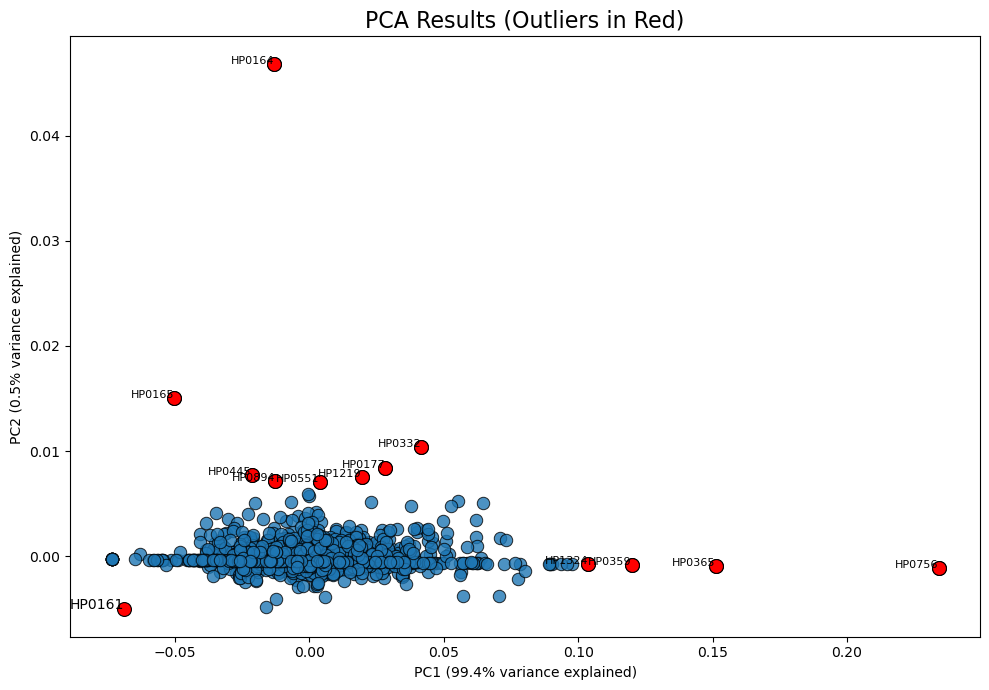

In [110]:

# Plot the PCA results
plt.figure(figsize=(10, 7))

# Plot all points in single color
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df,
    s=80,
    alpha=0.8,
    edgecolor='k'
)

# Plot outliers in red 
sns.scatterplot(
    x='PC1', y='PC2', data=outliers,
    color='red', s=100, alpha=1, edgecolor='k'
)

# Label outliers with gene names
for i, row in outliers.iterrows():
    plt.text(row['PC1'], row['PC2'], row['Gene'], fontsize=8, ha='right')

# Get coordinates of bottom left point
specific_point = pca_df.loc[(pca_df['PC1'] < -0.05) & (pca_df['PC2'] < -0.005)]  

# Label specific point
for i, row in specific_point.iterrows():
    plt.text(row['PC1'], row['PC2'], row['Gene'], fontsize=10, ha='right', color='black')
    
#outliers = outliers.append(specific_point) - append no longer supported 
outliers = pd.concat([outliers, pd.DataFrame(specific_point)], ignore_index = True)

    
sns.scatterplot(
    x='PC1', y='PC2', data=outliers,
    color='red', s=100, alpha=1, edgecolor='k'
)

# Add title to the plot
plt.title('PCA Results (Outliers in Red)', fontsize=16)


# Label axes with variance 
plt.xlabel(f'PC1 ({gene_pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
plt.ylabel(f'PC2 ({gene_pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')

# Adjust legend and layout
#plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.legend([],[], frameon=False)  # Remove legend
plt.show()
